# Label Analysis
Base rates, temporal patterns, and label timelines across all six parks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

DATA = Path('../data/processed')
PLOTS = Path('../results/plots')
PLOTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / 'featured_dataset.csv', index_col='date', parse_dates=True)
PARKS = df['park'].unique()
LABELS = ['fire_within_30d', 'drought_within_30d', 'vegetation_within_30d']
COLORS = {'fire_within_30d': '#d62728', 'drought_within_30d': '#ff7f0e', 'vegetation_within_30d': '#2ca02c'}
print(f'Loaded {len(df):,} rows | Parks: {list(PARKS)}')

Loaded 12,792 rows | Parks: ['yankari', 'kainji_lake', 'cross_river', 'chad_basin', 'old_oyo', 'gashaka_gumti']


## 1. Base rates by park and threat

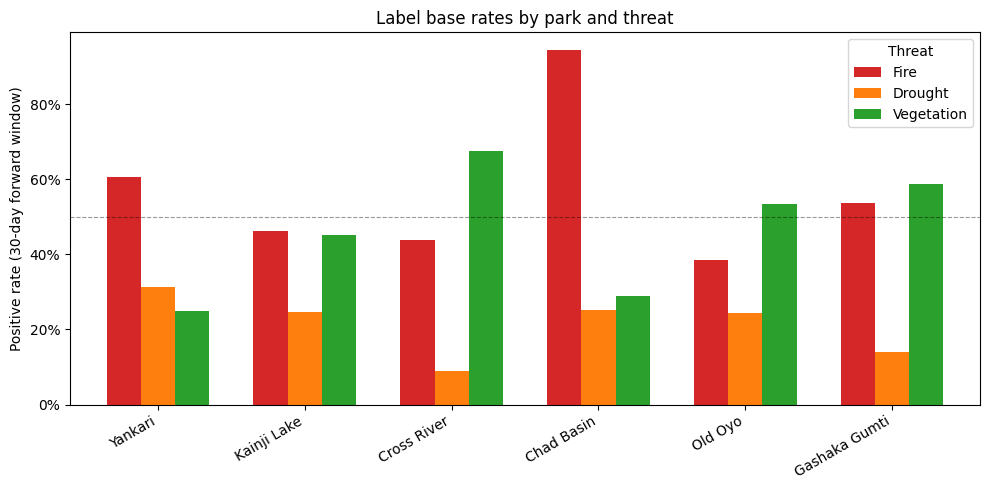

                   Fire   Drought  Vegetation
yankari        0.606565  0.313511    0.249286
kainji_lake    0.461941  0.246908    0.451951
cross_river    0.438630  0.088963    0.674120
chad_basin     0.943863  0.252617    0.289724
old_oyo        0.384872  0.243578    0.533302
gashaka_gumti  0.537583  0.141294    0.587060


In [2]:
rates = {}
for park in PARKS:
    p = df[df['park'] == park]
    rates[park] = {col: p[col].mean(skipna=True) for col in LABELS}

rates_df = pd.DataFrame(rates).T
rates_df.columns = ['Fire', 'Drought', 'Vegetation']

fig, ax = plt.subplots(figsize=(10, 5))
rates_df.plot(kind='bar', ax=ax, color=['#d62728','#ff7f0e','#2ca02c'], width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('')
ax.set_ylabel('Positive rate (30-day forward window)')
ax.set_title('Label base rates by park and threat')
ax.set_xticklabels([p.replace('_', ' ').title() for p in rates_df.index], rotation=30, ha='right')
ax.legend(title='Threat')
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.savefig(PLOTS / 'label_base_rates.png', dpi=150)
plt.show()
print(rates_df.to_string())

## 2. Monthly threat seasonality (pooled across all parks)

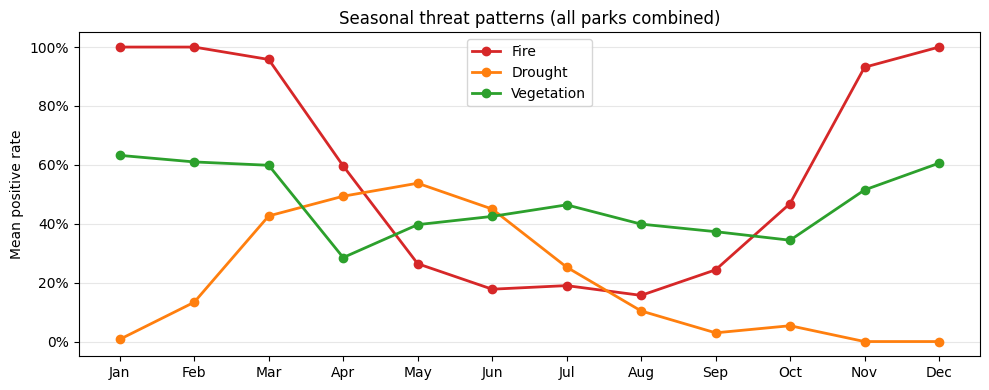

In [3]:
df['month'] = df.index.month
monthly = df.groupby('month')[LABELS].mean()
monthly.columns = ['Fire', 'Drought', 'Vegetation']

fig, ax = plt.subplots(figsize=(10, 4))
for col, color in zip(monthly.columns, ['#d62728','#ff7f0e','#2ca02c']):
    ax.plot(monthly.index, monthly[col], marker='o', color=color, label=col, linewidth=2)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Mean positive rate')
ax.set_title('Seasonal threat patterns (all parks combined)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / 'seasonal_threat_patterns.png', dpi=150)
plt.show()

## 3. Label timelines per park (annual heatmap)

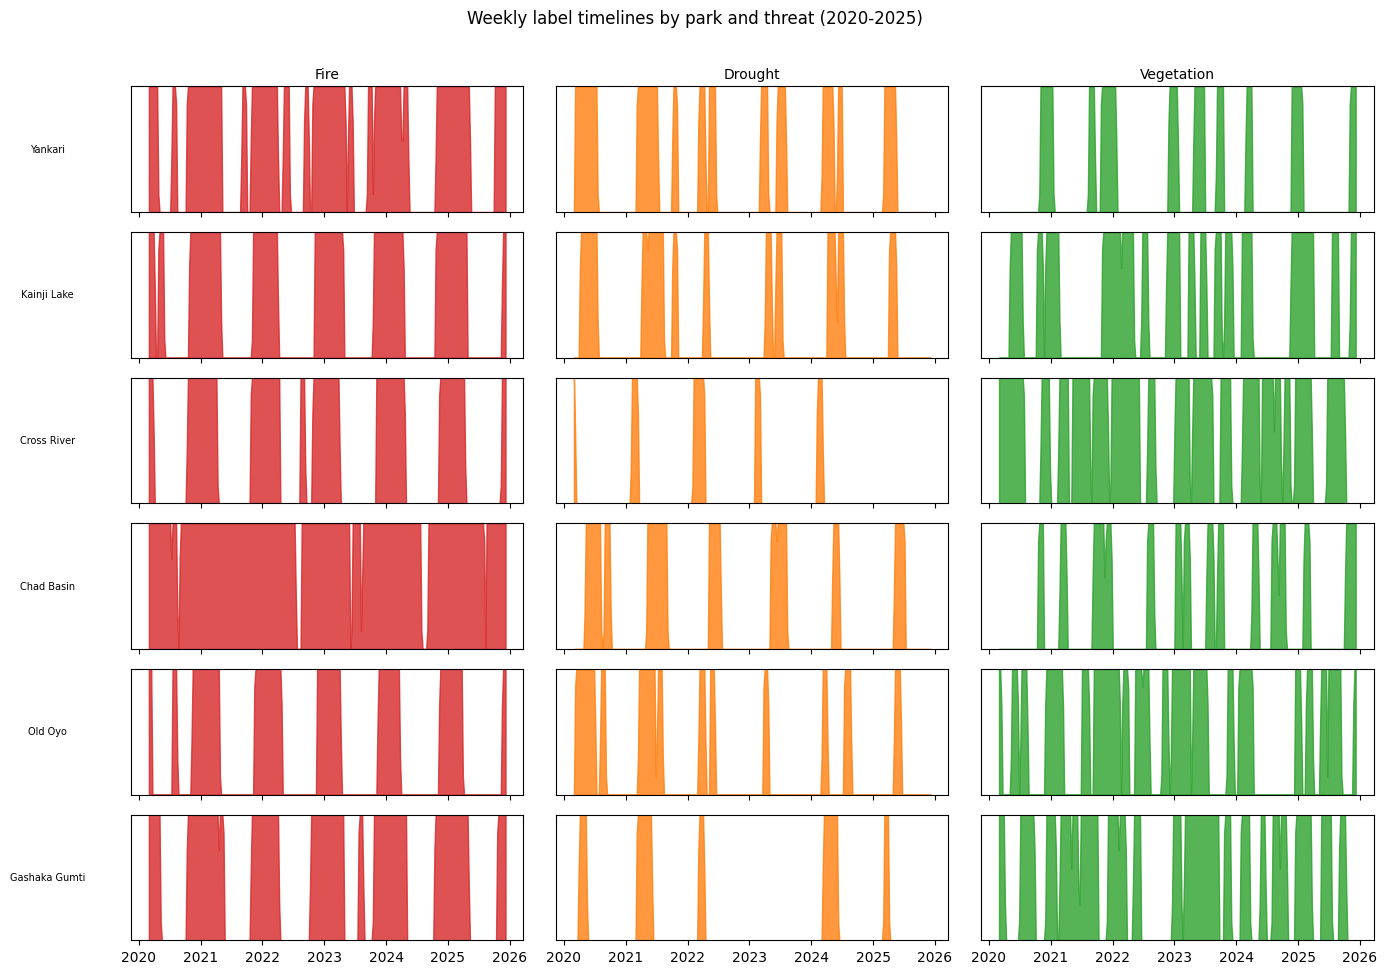

In [4]:
fig, axes = plt.subplots(len(PARKS), 3, figsize=(14, len(PARKS)*1.6), sharex=True)
label_names = ['Fire', 'Drought', 'Vegetation']

for i, park in enumerate(PARKS):
    p = df[df['park'] == park][LABELS].resample('W').mean()
    for j, (col, name) in enumerate(zip(LABELS, label_names)):
        ax = axes[i][j]
        ax.fill_between(p.index, p[col], alpha=0.8, color=COLORS[col])
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        if i == 0:
            ax.set_title(name, fontsize=10)
        if j == 0:
            ax.set_ylabel(park.replace('_',' ').title(), fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Weekly label timelines by park and threat (2020-2025)', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'label_timelines.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Train / val / test split verification

In [5]:
split_counts = df.groupby(['park','split']).size().unstack(fill_value=0)
print('Row counts per park per split:')
print(split_counts)
print()
print('Overall:')
print(df['split'].value_counts())

Row counts per park per split:
split          test  train  val
park                           
chad_basin      731   1217  184
cross_river     731   1217  184
gashaka_gumti   731   1217  184
kainji_lake     731   1217  184
old_oyo         731   1217  184
yankari         731   1217  184

Overall:
split
train    7302
test     4386
val      1104
Name: count, dtype: int64


## 5. Test set positive counts (flag parks with <30 positives)

In [6]:
test = df[df['split'] == 'test']
rows = []
for park in PARKS:
    p = test[test['park'] == park]
    for col, name in zip(LABELS, ['Fire','Drought','Vegetation']):
        n = int(p[col].sum(skipna=True))
        rows.append({'park': park, 'threat': name, 'positives': n, 'flag': '⚠' if n < 30 else ''})
result = pd.DataFrame(rows).pivot(index='park', columns='threat', values='positives')
print(result)
print('\nNote: Cross River drought has only 36 positives — metrics will be unreliable.')

threat         Drought  Fire  Vegetation
park                                    
chad_basin         108   653         219
cross_river         36   288         465
gashaka_gumti      119   372         381
kainji_lake        138   310         274
old_oyo            119   238         301
yankari            175   390         143

Note: Cross River drought has only 36 positives — metrics will be unreliable.
